In [110]:
from sklearn.experimental import enable_iterative_imputer
import pandas as pd
import numpy as np
from joblib import load
from data_preprocessing import preprocess_data
from model_comparison import compare_models, print_comparison_report
from tender_recommender import evaluate_recommendations, print_evaluation_results, visualize_evaluation_results, plot_metrics_comparison
import matplotlib.pyplot as plt
import re
from sklearn.metrics import roc_auc_score, average_precision_score
import random
from tender_recommender import get_recommendations

In [206]:
df_1 = pd.read_excel('correct_initial_data.xlsx')
df_2 = pd.read_excel('spark_data.xlsx')

In [245]:
df = df_1.merge(df_2, on='ИНН поставщика', how='left')
df_processed = preprocess_data(df)

/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [228]:
unique_tenders = df.drop_duplicates(subset=['Реестровый номер публикации'])
print(f"Найдено {len(unique_tenders)} уникальных тендеров")
sample_tender_row = unique_tenders.sample(n=1, random_state=42).iloc[0]

sample_tender = {
    'Стоимость(руб.) Заказчик': sample_tender_row['Стоимость(руб.) Заказчик'],
    'Сфера деятельности': sample_tender_row['Сфера деятельности'],
    'Регион поставки': sample_tender_row['Регион поставки'],
    'Город поставки': sample_tender_row['Город поставки'],
    'Дата публикации': sample_tender_row['Дата публикации'],
    'Уровень': sample_tender_row['Уровень'],
    'Тип торгов': sample_tender_row['Тип торгов'],
    'Заказчик': sample_tender_row['Заказчик'],
    'ИНН заказчика': sample_tender_row['ИНН заказчика'],
    'Обеспечение контракта (руб.)': sample_tender_row.get('Обеспечение контракта (руб.)', None),
    'Обеспечение контракта, %': sample_tender_row.get('Обеспечение контракта, %', None),
    'Реестровый номер публикации': sample_tender_row['Реестровый номер публикации'],
    'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ': 
        sample_tender_row.get('Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ', None),
    'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ': 
        sample_tender_row.get('Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ', None),
    'Дата окончания проведения торгов': sample_tender_row.get('Дата окончания проведения торгов', None)
}

Найдено 4881 уникальных тендеров


In [229]:
sample_tender

{'Стоимость(руб.) Заказчик': 759920.0,
 'Сфера деятельности': '[ОКПД2 42.22] Сооружения и строительные работы по строительству коммунальных объектов для электроснабжения и связи, [ОКВЭД2 42.22] Строительство коммунальных объектов для обеспечения электроэнергией и телекоммуникациями',
 'Регион поставки': 'Свердловская область',
 'Город поставки': 'Свердловская область',
 'Дата публикации': Timestamp('2019-01-24 11:00:46'),
 'Уровень': 2,
 'Тип торгов': nan,
 'Заказчик': 'АО "ОБЛКОММУНЭНЕРГО"',
 'ИНН заказчика': 6671028735,
 'Обеспечение контракта (руб.)': nan,
 'Обеспечение контракта, %': nan,
 'Реестровый номер публикации': '31907444921',
 'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ': Timestamp('2019-02-01 15:00:00'),
 'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ': Timestamp('2019-01-25 00:00:00'),
 'Дата окончания проведения торгов': datetime.datetime(2019, 3, 4, 9, 0)}

In [230]:
model_lgb = load('lgbm_info.joblib')

recommendations = get_recommendations(sample_tender, df_processed, model_lgb)


Найдено 4836 уникальных поставщиков в базе

Расчет количества конкурентов в тендере:
Всего уникальных тендеров: 4881
Среднее количество конкурентов в тендере: 0.02
Максимальное количество конкурентов: 3

Распределение количества конкурентов в тендерах:
  0 конкурентов: 4783 тендеров
  1 конкурентов: 91 тендеров
  2 конкурентов: 5 тендеров
  3 конкурентов: 2 тендеров

Размер DataFrame после объединения: (8662, 11)
Столбцы после объединения: ['ИНН поставщика', 'Поставщик', 'Регион поставки', 'Сфера деятельности', 'Город поставщика', 'Субъект поставщика', 'Допущен', 'Кол-во конкурентов в тендере', 'Процент побед', 'Процент побед по региону']...

Статистика по столбцам перед заполнением:
  'Процент побед': 8662 непустых значений (0.0% пропусков)
  'Процент побед по региону': 8662 непустых значений (0.0% пропусков)
  'Среднее кол-во конкурентов у заказчика': 8662 непустых значений (0.0% пропусков)
  'Кол-во конкурентов в тендере': 8662 непустых значений (0.0% пропусков)
  'Допущен': 8662 н

/Users/arinazajceva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [231]:
print("\nРекомендации:")
for i, rec in enumerate(recommendations, 1):
    print(f"\n{i}. {rec['name']}")
    print(f"   ИНН: {rec['inn']}")
    print(f"   Вероятность победы: {rec['probability']}%")
    print(f"   Регион: {rec['region']}")
    print(f"   Сфера деятельности: {rec['sector']}")
    print(f"   Процент побед: {rec['win_rate']}%")


Рекомендации:

1. ООО"АГЕНТСТВО ПБ"
   ИНН: 3849070973
   Вероятность победы: 99.996%
   Регион: Кемеровская область
   Сфера деятельности: [ОКПД2 84.25] Услуги по обеспечению безопасности в чрезвычайных ситуациях; услуги по обеспечению безопасности в области использования атомной энергии, [ОКВЭД2 84.25] Деятельность по обеспечению безопасности в чрезвычайных ситуациях; деятельность по обеспечению безопасности в области использования атомной энергии
   Процент побед: 66.6667%

2. ООО "ВЕЛОКС"
   ИНН: 7801347110
   Вероятность победы: 99.996%
   Регион: Оренбургская область
   Сфера деятельности: [ОКПД2 14+] Одежда, [ОКВЭД2 46.42] Торговля оптовая одеждой и обувью
   Процент побед: 70.0%

3. ООО "СТРОЙЭНЕРГОГАЗ"
   ИНН: 6453154240
   Вероятность победы: 99.996%
   Регион: Тамбовская область
   Сфера деятельности: [ОКПД2 28.14] Арматура трубопроводная (арматура) (краны, клапаны и прочие), [ОКВЭД2 28.14] Производство арматуры трубопроводной (арматуры)
   Процент побед: 66.6667%

4. ООО "

In [254]:
df_processed.shape

(492078, 52)

In [325]:
shorter_data = df_processed.sample(n=200000, random_state=42)

In [385]:
model_lgb_full = load('lgbm_info.joblib')

results_lgb_full = evaluate_recommendations(df_processed, model_lgb_full, num_tenders=100, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 329272

Найдено 215334 тендеров с победителями
Будет оценено 100 тендеров


In [326]:
results_lgb = evaluate_recommendations(shorter_data, model_lgb, num_tenders=200, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 154209

Найдено 89877 тендеров с победителями
Будет оценено 200 тендеров



=== Метрики качества ===

Метрики для top-1:
Precision@1: 0.1587 ± 0.3654
Recall@1: 0.0464 ± 0.1629
NDCG@1: 0.1587 ± 0.3654

Метрики для top-3:
Precision@3: 0.1582 ± 0.3151
Recall@3: 0.0957 ± 0.2266
NDCG@3: 0.1721 ± 0.3295

Метрики для top-5:
Precision@5: 0.1724 ± 0.3247
Recall@5: 0.1640 ± 0.3314
NDCG@5: 0.2039 ± 0.3499

Метрики для top-10:
Precision@10: 0.1164 ± 0.2688
Recall@10: 0.1851 ± 0.3414
NDCG@10: 0.1752 ± 0.3087

Метрики для top-20:
Precision@20: 0.1432 ± 0.2969
Recall@20: 0.2985 ± 0.4171
NDCG@20: 0.2175 ± 0.3270

=== Глобальные метрики ===
ROC AUC: 0.6436 ± 0.2447
Average Precision: 0.3072 ± 0.2747
Mean Recall: 0.1484 ± 0.3113


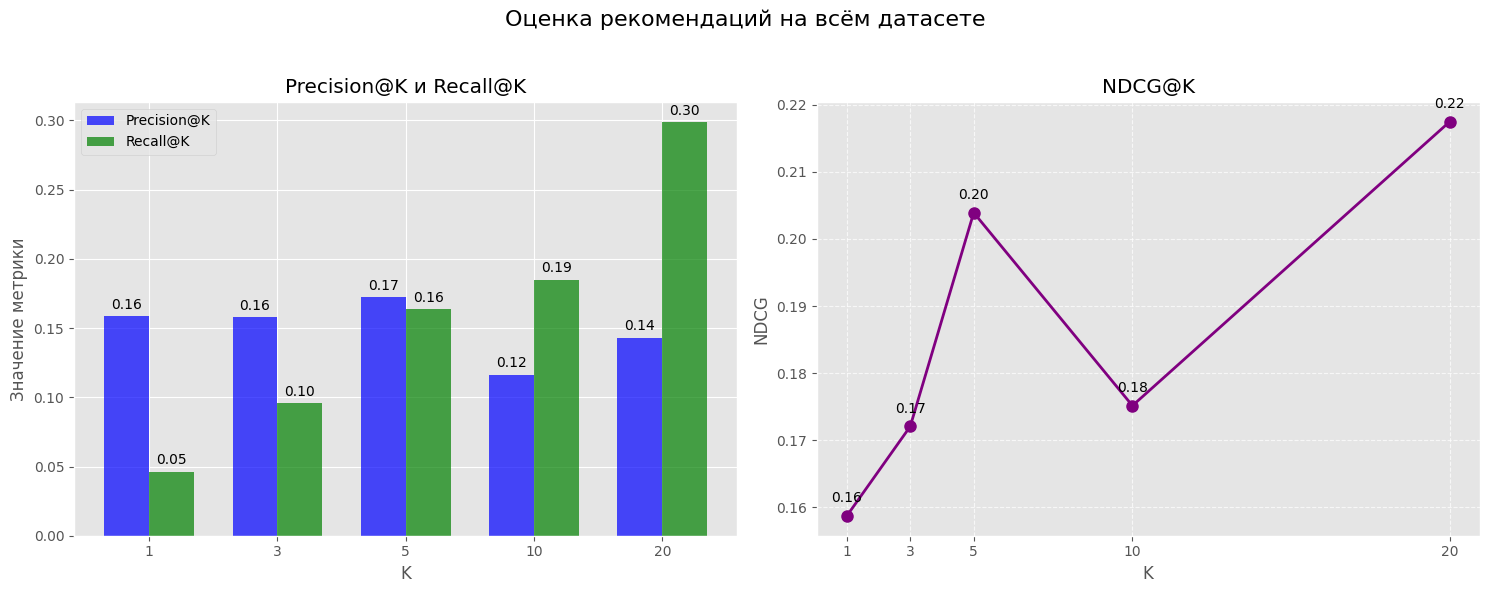

In [430]:
print_evaluation_results(results_lgb)
fig = visualize_evaluation_results(results_lgb, title="Оценка рекомендаций на всём датасете")

plt.show()

Это на обрезанных данных (200 тысяч строк) и большее количество тендеров - 200 штук вместо 100

In [381]:
model_xgb = load('xgboost_info.joblib')

results_xgb = evaluate_recommendations(df_processed, model_xgb, num_tenders=200, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 329272

Найдено 215334 тендеров с победителями
Будет оценено 200 тендеров



=== Метрики качества ===

Метрики для top-1:
Precision@1: 0.1286 ± 0.3347
Recall@1: 0.0436 ± 0.1727
NDCG@1: 0.1286 ± 0.3347

Метрики для top-3:
Precision@3: 0.0966 ± 0.2668
Recall@3: 0.0592 ± 0.1821
NDCG@3: 0.1096 ± 0.2903

Метрики для top-5:
Precision@5: 0.0985 ± 0.2557
Recall@5: 0.0779 ± 0.2244
NDCG@5: 0.1091 ± 0.2761

Метрики для top-10:
Precision@10: 0.0683 ± 0.1753
Recall@10: 0.1126 ± 0.2867
NDCG@10: 0.1104 ± 0.2554

Метрики для top-20:
Precision@20: 0.0445 ± 0.1494
Recall@20: 0.0880 ± 0.2396
NDCG@20: 0.0682 ± 0.1803

=== Глобальные метрики ===
ROC AUC: 0.6113 ± 0.2324
Average Precision: 0.3151 ± 0.2862
Mean Recall: 0.0749 ± 0.2241


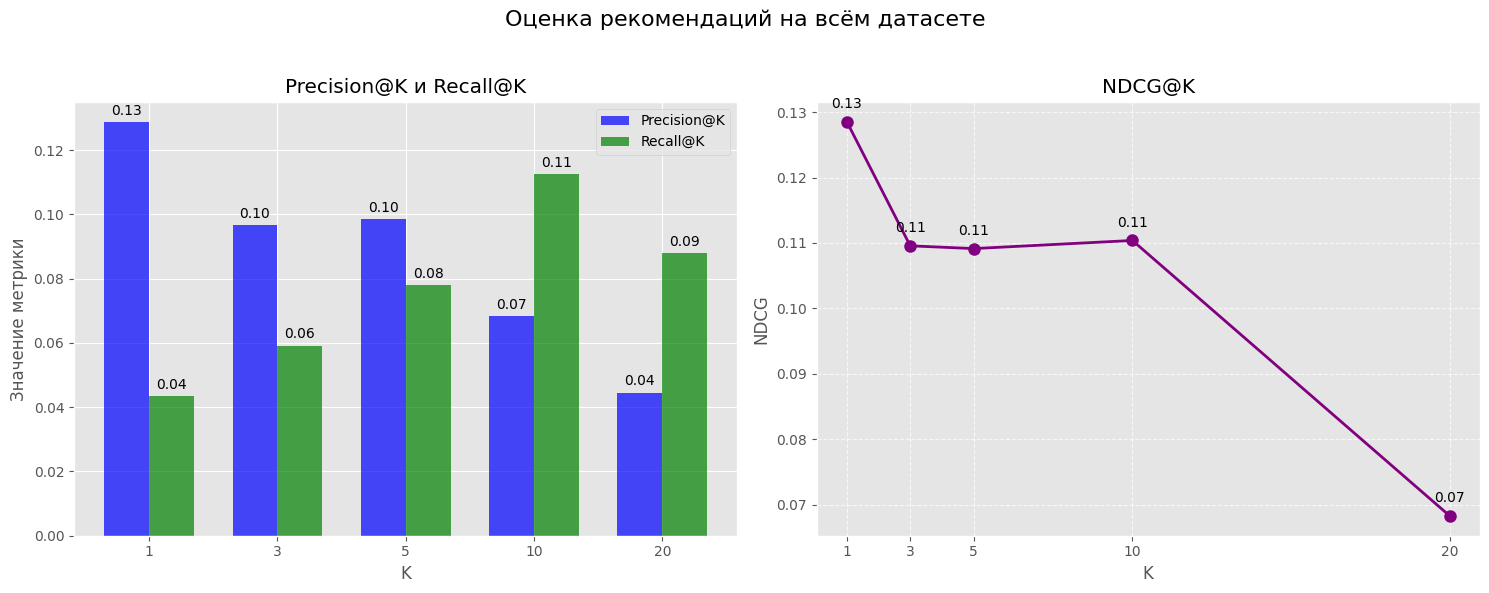

In [428]:
print_evaluation_results(results_xgb)
fig = visualize_evaluation_results(results_xgb, title="Оценка рекомендаций на всём датасете")

plt.show()

In [377]:
model_ada = load('adaboost_info.joblib')

results_ada = evaluate_recommendations(df_processed, model_ada, num_tenders=100, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 329272

Найдено 215334 тендеров с победителями
Будет оценено 100 тендеров



=== Метрики качества ===

Метрики для top-1:
Precision@1: 0.0833 ± 0.2764
Recall@1: 0.0561 ± 0.2290
NDCG@1: 0.0833 ± 0.2764

Метрики для top-3:
Precision@3: 0.0667 ± 0.1919
Recall@3: 0.0572 ± 0.1883
NDCG@3: 0.0834 ± 0.2420

Метрики для top-5:
Precision@5: 0.0667 ± 0.1949
Recall@5: 0.0628 ± 0.1916
NDCG@5: 0.0726 ± 0.2091

Метрики для top-10:
Precision@10: 0.0667 ± 0.1949
Recall@10: 0.0928 ± 0.2469
NDCG@10: 0.0896 ± 0.2291

Метрики для top-20:
Precision@20: 0.0483 ± 0.1864
Recall@20: 0.0583 ± 0.1486
NDCG@20: 0.0644 ± 0.1989

=== Глобальные метрики ===
ROC AUC: 0.6690 ± 0.2491
Average Precision: 0.3007 ± 0.2786
Mean Recall: 0.0653 ± 0.2057


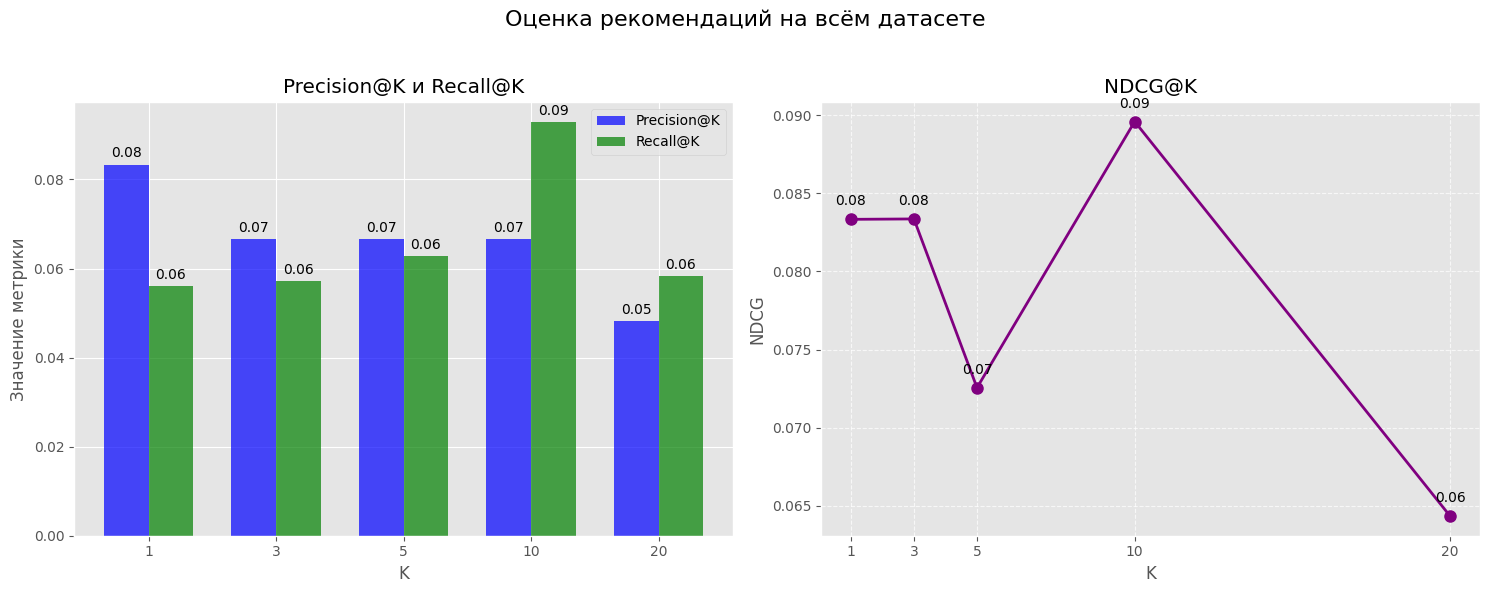

In [429]:
print_evaluation_results(results_ada)
fig = visualize_evaluation_results(results_ada, title="Оценка рекомендаций на всём датасете")

plt.show()

In [369]:
def calculate_company_features(company_data, historical_data):
    """
    Расчет признаков для компании на основе исторических данных
    """
    features = {}
    company_inn = company_data['ИНН поставщика']
    
    # В оригинале фильтрация идет и по ИНН, и по имени поставщика
    # В версии для CatBoost только по ИНН:
    company_history = historical_data[historical_data['ИНН поставщика'] == company_inn]
    
    # В оригинале признаки инициализируются как None
    # В версии для CatBoost сразу задаются нулевые значения
    features['Кол-во конкурентов в тендере'] = 0.0
    features['Процент побед'] = 0.0
    features['Процент побед по региону'] = 0.0
    features['Среднее кол-во конкурентов у заказчика'] = 0.0
    features['Допущен'] = 1.0  # По умолчанию считаем, что компания допущена
    
    if len(company_history) > 0:
        # В оригинале используется колонка 'Победитель'
        # В версии для CatBoost используется 'Target'
        company_wins = (company_history['Target'] == 1).sum()
        total_participations = len(company_history)
        
        if total_participations > 0:
            features['Процент побед'] = company_wins / total_participations
        
        current_region = company_data.get('Регион поставки')
        if current_region and not pd.isna(current_region):
            region_history = company_history[company_history['Регион поставки'] == current_region]
            if len(region_history) > 0:
                region_wins = (region_history['Target'] == 1).sum()
                features['Процент побед по региону'] = region_wins / len(region_history)
    
    # В оригинале есть дополнительная логика поиска customer_inn через имя заказчика
    # В версии для CatBoost эта логика удалена
    customer_inn = company_data.get('ИНН заказчика')
    if customer_inn and not pd.isna(customer_inn):
        customer_tenders = historical_data[historical_data['ИНН заказчика'] == customer_inn]
        if not customer_tenders.empty:
            competitors_per_tender = customer_tenders.groupby('Реестровый номер публикации')['ИНН поставщика'].nunique()
            features['Среднее кол-во конкурентов у заказчика'] = competitors_per_tender.mean()
    
    for key in features:
        if pd.isna(features[key]) or features[key] is None:
            features[key] = 0.0
        elif isinstance(features[key], (int, float)):
            features[key] = float(features[key])
    
    return features

def evaluate_recommendations(df, model, num_tenders=100, k_values=[1, 3, 5, 10, 20], random_seed=42, min_suppliers=1):
    """
    Оценивает качество рекомендаций на исторических данных.
    """

    np.random.seed(random_seed)
    random.seed(random_seed)
    
    def precision_at_k(y_true, y_pred, k):
        if len(y_pred) < k:
            return 0.0
        return np.mean(y_true[np.argsort(-y_pred)[:k]])
    
    def recall_at_k(y_true, y_pred, k):
        if np.sum(y_true) == 0:
            return 0.0
        if len(y_pred) < k:
            return np.sum(y_true[np.argsort(-y_pred)]) / np.sum(y_true)
        return np.sum(y_true[np.argsort(-y_pred)[:k]]) / np.sum(y_true)
    
    def ndcg_at_k(y_true, y_pred, k):
        if len(y_pred) < k:
            k = len(y_pred)
        if np.sum(y_true) == 0:
            return 0.0
        idx = np.argsort(-y_pred)[:k]
        dcg = np.sum(y_true[idx] / np.log2(np.arange(2, k + 2)))
        idx_ideal = np.argsort(-y_true)[:k]
        idcg = np.sum(y_true[idx_ideal] / np.log2(np.arange(2, k + 2)))
        return dcg / idcg if idcg > 0 else 0.0

    print("Проверяем доступность колонок в данных...")
    
    tender_id_column = 'Реестровый номер публикации'
    target_column = 'Target'
    supplier_id_column = 'ИНН поставщика'
    
    required_features = [
        'Процент побед',
        'Процент побед по региону',
        'Среднее кол-во конкурентов у заказчика',
        'Кол-во конкурентов в тендере',
        'Уровень',
        'Допущен'
    ]
    
    company_columns = [col for col in [supplier_id_column, 'Регион поставки', 
                                     'Сфера деятельности', 'Субъект поставщика'] 
                      if col in df.columns]
    
    companies_db = df[company_columns].drop_duplicates()
    print(f"Всего уникальных компаний в базе: {len(companies_db)}")
    
    winner_counts = df.groupby(tender_id_column)[target_column].sum()
    valid_tenders = winner_counts[winner_counts > 0].index.tolist()
    print(f"\nНайдено {len(valid_tenders)} тендеров с победителями")
    
    if len(valid_tenders) == 0:
        print(f"Ошибка: В данных нет тендеров с победителями.")
        return {
            'error': 'Нет тендеров с победителями',
            'num_evaluated_tenders': 0
        }
    
    filtered_df = df[df[tender_id_column].isin(valid_tenders)].copy()
    unique_tenders = filtered_df.drop_duplicates(subset=[tender_id_column])
    
    if len(unique_tenders) > num_tenders:
        test_tenders = unique_tenders.sample(n=num_tenders, random_state=random_seed)
    else:
        test_tenders = unique_tenders
    
    print(f"Будет оценено {len(test_tenders)} тендеров")
    
    metrics = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in k_values}
    metrics['auc'] = []
    metrics['ap'] = []
    
    processed_tenders = 0
    skipped_tenders = 0
    successful_tenders = 0
    
    # Получаем компоненты модели один раз перед циклом
    pipeline, preprocessor, classifier = get_model_components(model)
    
    for i, (_, tender) in enumerate(test_tenders.iterrows()):
        processed_tenders += 1
        tender_id = tender[tender_id_column]

        tender_data = {
            'Сфера деятельности': tender['Сфера деятельности'],
            'Регион поставки': tender['Регион поставки'],
            'Дата публикации': tender['Дата публикации'],
            'Уровень': tender.get('Уровень', 1),
            'Тип торгов': tender.get('Тип торгов', 'Не указан'),
            'ИНН заказчика': tender.get('ИНН заказчика'),
            'Заказчик': tender.get('Заказчик')
        }
        
        actual_data = filtered_df[filtered_df[tender_id_column] == tender_id].copy()
        actual_winners = actual_data[actual_data[target_column] == 1][supplier_id_column].unique()
        
        if len(actual_winners) == 0:
            skipped_tenders += 1
            continue
        
        try:
            candidates = get_candidate_companies(tender_data, companies_db, df, top_n=1000)
            
            if len(candidates) < min_suppliers:
                skipped_tenders += 1
                continue
            
            # Тут используем обновленную версию calculate_company_features
            for idx, company in candidates.iterrows():
                company_features = calculate_company_features(company, df)
                for key, value in company_features.items():
                    candidates.at[idx, key] = value
            
            # Проверяем наличие всех необходимых признаков
            for feature in required_features:
                if feature not in candidates.columns:
                    if feature == 'Уровень':
                        candidates[feature] = tender_data.get('Уровень', 1)
                    elif feature == 'Допущен':
                        candidates[feature] = 1
                    else:
                        candidates[feature] = 0.0
            
            # Упрощенная обработка признаков для CatBoost
            X_pred = candidates[required_features].copy()
            
            for col in X_pred.columns:
                X_pred[col] = pd.to_numeric(X_pred[col], errors='coerce').fillna(0)
            
            if hasattr(classifier, 'predict_proba'):
                y_pred = classifier.predict_proba(X_pred)[:, 1]
            else:
                y_pred = classifier.predict(X_pred)
            
            y_true = np.zeros(len(candidates))
            for i, candidate in enumerate(candidates[supplier_id_column]):
                if candidate in actual_winners:
                    y_true[i] = 1
            
            for k in k_values:
                if k <= len(y_pred):
                    precision = precision_at_k(y_true, y_pred, k)
                    recall = recall_at_k(y_true, y_pred, k)
                    ndcg = ndcg_at_k(y_true, y_pred, k)
                    
                    metrics[k]['precision'].append(precision)
                    metrics[k]['recall'].append(recall)
                    metrics[k]['ndcg'].append(ndcg)
            
            if len(np.unique(y_true)) > 1:
                try:
                    auc = roc_auc_score(y_true, y_pred)
                    ap = average_precision_score(y_true, y_pred)
                    metrics['auc'].append(auc)
                    metrics['ap'].append(ap)
                except Exception as e:
                    print(f"Ошибка при расчете AUC/AP: {str(e)}")
            
            successful_tenders += 1
            
        except Exception as e:
            print(f"Ошибка при обработке тендера: {str(e)}")
            skipped_tenders += 1
            continue
    
    results = {
        'processed_tenders': processed_tenders,
        'skipped_tenders': skipped_tenders,
        'successful_tenders': successful_tenders,
        'total_tenders': len(test_tenders)
    }
    
    if successful_tenders > 0:
        for k in k_values:
            if metrics[k]['precision']:
                results[f'precision@{k}'] = float(np.mean(metrics[k]['precision']))
                results[f'recall@{k}'] = float(np.mean(metrics[k]['recall']))
                results[f'ndcg@{k}'] = float(np.mean(metrics[k]['ndcg']))
                results[f'precision@{k}_std'] = float(np.std(metrics[k]['precision']))
                results[f'recall@{k}_std'] = float(np.std(metrics[k]['recall']))
                results[f'ndcg@{k}_std'] = float(np.std(metrics[k]['ndcg']))
                results[f'precision@{k}_min'] = float(np.min(metrics[k]['precision']))
                results[f'precision@{k}_max'] = float(np.max(metrics[k]['precision']))
                results[f'recall@{k}_min'] = float(np.min(metrics[k]['recall']))
                results[f'recall@{k}_max'] = float(np.max(metrics[k]['recall']))
            else:
                results[f'precision@{k}'] = 0.0
                results[f'recall@{k}'] = 0.0
                results[f'ndcg@{k}'] = 0.0
                results[f'precision@{k}_std'] = 0.0
                results[f'recall@{k}_std'] = 0.0
                results[f'ndcg@{k}_std'] = 0.0
                results[f'precision@{k}_min'] = 0.0
                results[f'precision@{k}_max'] = 0.0
                results[f'recall@{k}_min'] = 0.0
                results[f'recall@{k}_max'] = 0.0
        
        all_recalls = []
        for k in k_values:
            if metrics[k]['recall']:
                all_recalls.extend(metrics[k]['recall'])
        results['mean_recall'] = float(np.mean(all_recalls)) if all_recalls else 0.0
        results['mean_recall_std'] = float(np.std(all_recalls)) if all_recalls else 0.0
        
        results['roc_auc'] = float(np.mean(metrics['auc'])) if metrics['auc'] else 0.0
        results['roc_auc_std'] = float(np.std(metrics['auc'])) if metrics['auc'] else 0.0
        results['average_precision'] = float(np.mean(metrics['ap'])) if metrics['ap'] else 0.0
        results['average_precision_std'] = float(np.std(metrics['ap'])) if metrics['ap'] else 0.0
    else:
        for k in k_values:
            results[f'precision@{k}'] = 0.0
            results[f'recall@{k}'] = 0.0
            results[f'ndcg@{k}'] = 0.0
            results[f'precision@{k}_std'] = 0.0
            results[f'recall@{k}_std'] = 0.0
            results[f'ndcg@{k}_std'] = 0.0
            results[f'precision@{k}_min'] = 0.0
            results[f'precision@{k}_max'] = 0.0
            results[f'recall@{k}_min'] = 0.0
            results[f'recall@{k}_max'] = 0.0
        
        results['mean_recall'] = 0.0
        results['mean_recall_std'] = 0.0
        results['roc_auc'] = 0.0
        results['roc_auc_std'] = 0.0
        results['average_precision'] = 0.0
        results['average_precision_std'] = 0.0
    
    return results

Если использовать ту же версию кода, то для Catboost будет выдавать ошибку, потому что другие модели использовали pipeline с preprocessor, а CatBoost обучался на сырых числовых данных без предобработки

In [370]:
model_cat = load('catboost_info.joblib')

results_cat = evaluate_recommendations(df_processed, model_cat, num_tenders=100, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 328982

Найдено 215334 тендеров с победителями
Будет оценено 100 тендеров
Лучшие параметры: {'auto_class_weights': 'SqrtBalanced', 'bagging_temperature': 0.6803075385877797, 'border_count': 104, 'depth': 5, 'grow_policy': 'SymmetricTree', 'iterations': 415, 'l2_leaf_reg': 0.004294199118583401, 'learning_rate': 0.037094276752507684, 'random_strength': 1.3921828195600071e-08}
Лучший CV score: 0.8282
Признаки при обучении (6): ['Процент побед', 'Процент побед по региону', 'Среднее кол-во конкурентов у заказчика', 'Кол-во конкурентов в тендере', 'Уровень', 'Допущен']...
Тип модели: <class 'catboost.core.CatBoostClassifier'>



=== Метрики качества ===

Метрики для top-1:
Precision@1: 0.0833 ± 0.2764
Recall@1: 0.0329 ± 0.1648
NDCG@1: 0.0833 ± 0.2764

Метрики для top-3:
Precision@3: 0.0571 ± 0.2029
Recall@3: 0.0419 ± 0.1737
NDCG@3: 0.0630 ± 0.2143

Метрики для top-5:
Precision@5: 0.0545 ± 0.2162
Recall@5: 0.0253 ± 0.1015
NDCG@5: 0.0541 ± 0.2147

Метрики для top-10:
Precision@10: 0.0758 ± 0.2189
Recall@10: 0.1020 ± 0.2780
NDCG@10: 0.0803 ± 0.2284

Метрики для top-20:
Precision@20: 0.0431 ± 0.1375
Recall@20: 0.1000 ± 0.2948
NDCG@20: 0.0807 ± 0.2471

=== Глобальные метрики ===
ROC AUC: 0.3684 ± 0.3839
Average Precision: 0.3665 ± 0.3334
Mean Recall: 0.0587 ± 0.2144


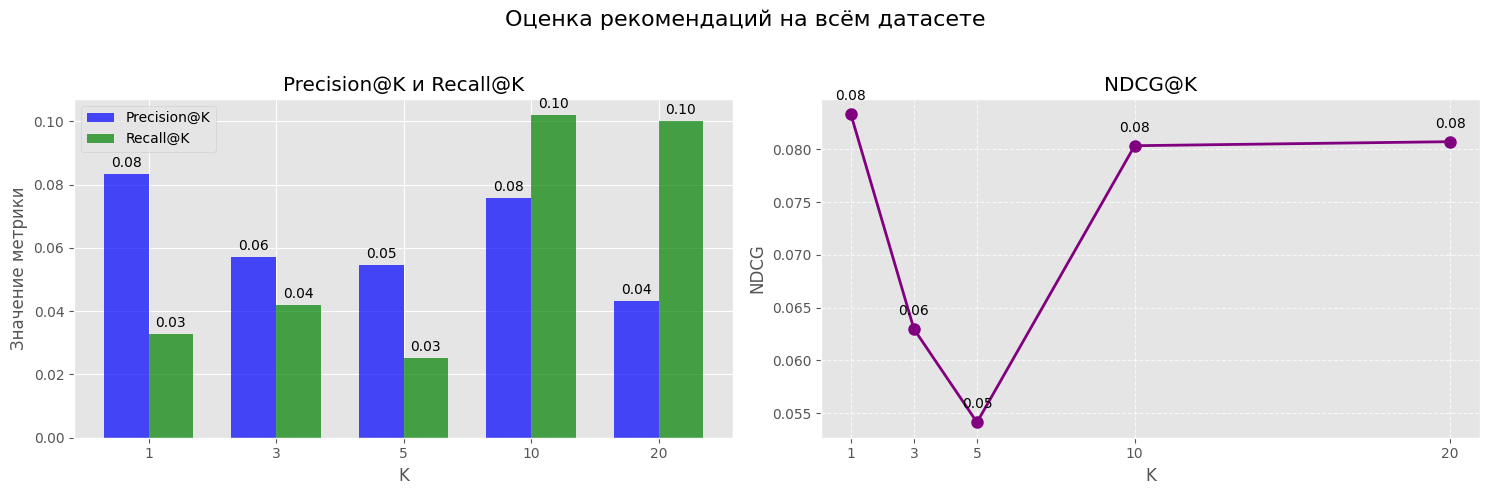

In [442]:
print_evaluation_results(results_cat)
fig = visualize_evaluation_results(results_cat, title="Оценка рекомендаций на всём датасете")

plt.show()

In [329]:
model_dt = load('decision_tree_info.joblib')

results_dt = evaluate_recommendations(df_processed, model_dt, num_tenders=100, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 329272

Найдено 215334 тендеров с победителями
Будет оценено 100 тендеров



=== Метрики качества ===

Метрики для top-1:
Precision@1: 0.0833 ± 0.2764
Recall@1: 0.0561 ± 0.2290
NDCG@1: 0.0833 ± 0.2764

Метрики для top-3:
Precision@3: 0.0476 ± 0.1413
Recall@3: 0.0496 ± 0.1856
NDCG@3: 0.0659 ± 0.2127

Метрики для top-5:
Precision@5: 0.0364 ± 0.1251
Recall@5: 0.0289 ± 0.1081
NDCG@5: 0.0391 ± 0.1351

Метрики для top-10:
Precision@10: 0.0424 ± 0.1349
Recall@10: 0.0664 ± 0.2382
NDCG@10: 0.0567 ± 0.1725

Метрики для top-20:
Precision@20: 0.0310 ± 0.1125
Recall@20: 0.0315 ± 0.0792
NDCG@20: 0.0346 ± 0.1191

=== Глобальные метрики ===
ROC AUC: 0.5000 ± 0.0000
Average Precision: 0.1985 ± 0.2043
Mean Recall: 0.0471 ± 0.1831


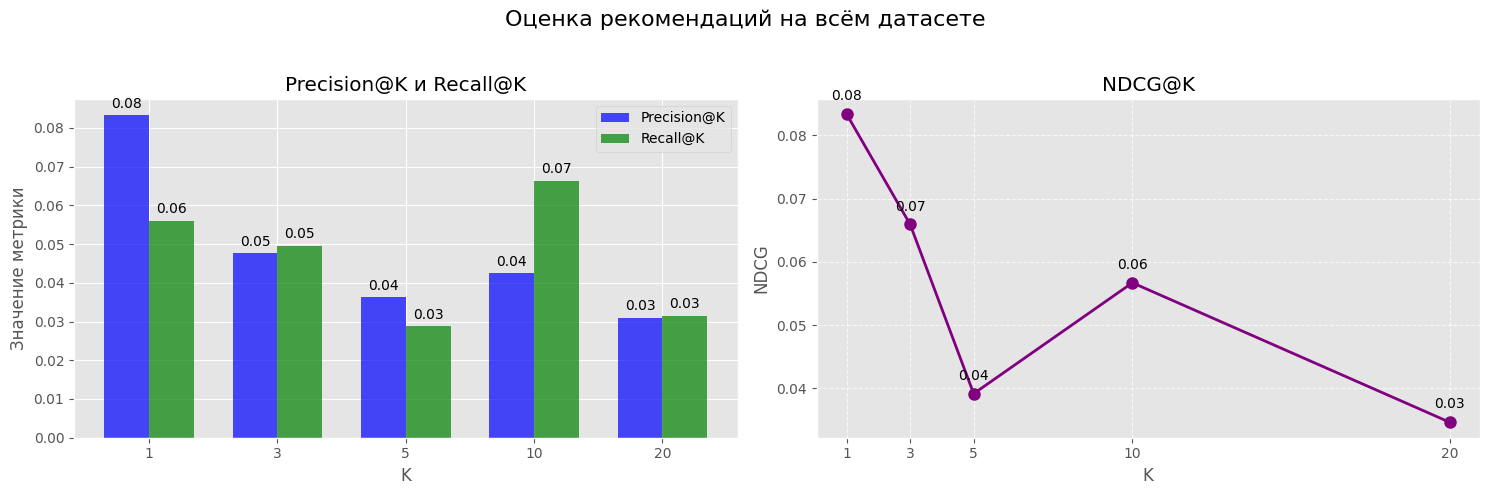

In [443]:
print_evaluation_results(results_dt)
fig = visualize_evaluation_results(results_dt, title="Оценка рекомендаций на всём датасете")

plt.show()

In [330]:
model_rf = load('random_forest_info.joblib')

results_rf = evaluate_recommendations(df_processed, model_rf, num_tenders=100, min_suppliers=1)

Проверяем доступность колонок в данных...
Всего уникальных компаний в базе: 329272

Найдено 215334 тендеров с победителями
Будет оценено 100 тендеров



=== Метрики качества ===

Метрики для top-1:
Precision@1: 0.0833 ± 0.2764
Recall@1: 0.0561 ± 0.2290
NDCG@1: 0.0833 ± 0.2764

Метрики для top-3:
Precision@3: 0.0571 ± 0.1866
Recall@3: 0.0501 ± 0.1856
NDCG@3: 0.0749 ± 0.2395

Метрики для top-5:
Precision@5: 0.0606 ± 0.1937
Recall@5: 0.0482 ± 0.1827
NDCG@5: 0.0636 ± 0.2065

Метрики для top-10:
Precision@10: 0.0545 ± 0.1908
Recall@10: 0.0690 ± 0.2390
NDCG@10: 0.0725 ± 0.2262

Метрики для top-20:
Precision@20: 0.0414 ± 0.1777
Recall@20: 0.0289 ± 0.1084
NDCG@20: 0.0442 ± 0.1837

=== Глобальные метрики ===
ROC AUC: 0.5428 ± 0.2177
Average Precision: 0.2734 ± 0.2470
Mean Recall: 0.0511 ± 0.1970


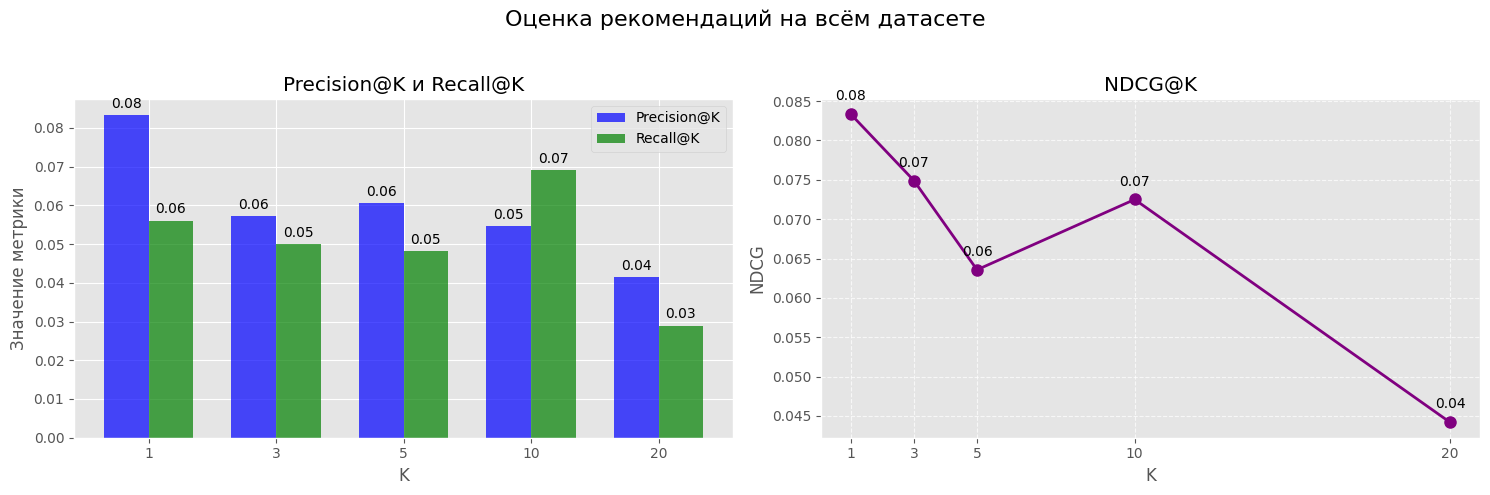

In [444]:
print_evaluation_results(results_rf)
fig = visualize_evaluation_results(results_rf, title="Оценка рекомендаций на всём датасете")

plt.show()


Статистика рангов:
        precision_rank  recall_rank  ndcg_rank
mean          3.500000     3.500000   3.500000
median        3.500000     3.500000   3.500000
std           1.691482     1.707825   1.707825

Значения метрик:
               ROC AUC  Avg Precision  Avg Recall  Avg NDCG
LightGBM      0.643600       0.307200    0.215900  0.198900
Decision Tree 0.500000       0.198500    0.042300  0.043500
Random Forest 0.542800       0.273400    0.048700  0.060100
XGBoost       0.659800       0.318000    0.056600  0.064000
CatBoost      0.368400       0.366500    0.075800  0.071700
AdaBoost      0.669000       0.300700    0.071300  0.075500


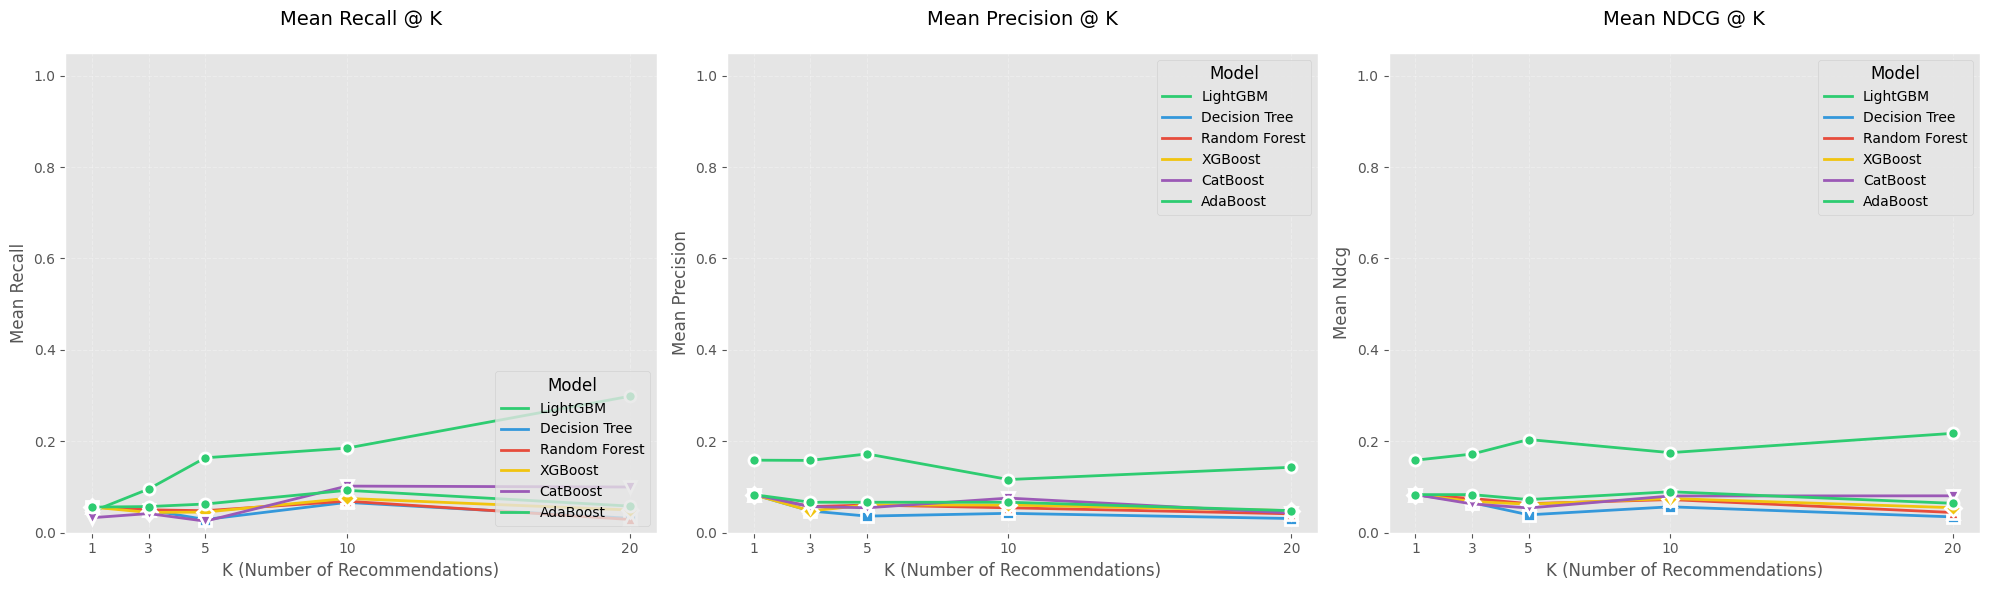

In [379]:
models_results = [results_lgb, results_dt, results_rf, results_xgb, results_cat, results_ada]
model_names = ['LightGBM', 'Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost', 'AdaBoost']

print_comparison_report(models_results, model_names)

metrics_fig = plot_metrics_comparison(
    models_results=models_results,
    model_names=model_names,
    k_values=[1, 3, 5, 10, 20]
)

Тут LightGBM отработан на данных по количеству в 2 раза меньше исходных, но на большем количестве тендеров (не 100, а 200)

Тут все модели на всех данных и на 100 случайных тендерах


Статистика рангов:
        precision_rank  recall_rank  ndcg_rank
mean          3.500000     3.500000   3.500000
median        3.500000     3.500000   3.500000
std           1.699673     1.707825   1.707825

Ранги моделей:
               Average Rank
XGBoost            1.444000
AdaBoost           2.333000
CatBoost           2.667000
Random Forest      3.889000
Decision Tree      4.833000
LightGBM           5.833000

Значения метрик:
               ROC AUC  Avg Precision  Avg Recall  Avg NDCG
LightGBM      0.521000       0.239700    0.037400  0.049000
Decision Tree 0.500000       0.198500    0.046500  0.055900
Random Forest 0.542800       0.273400    0.050500  0.067700
XGBoost       0.611300       0.315100    0.076200  0.105200
CatBoost      0.368400       0.366500    0.060400  0.072300
AdaBoost      0.669000       0.300700    0.065400  0.078600


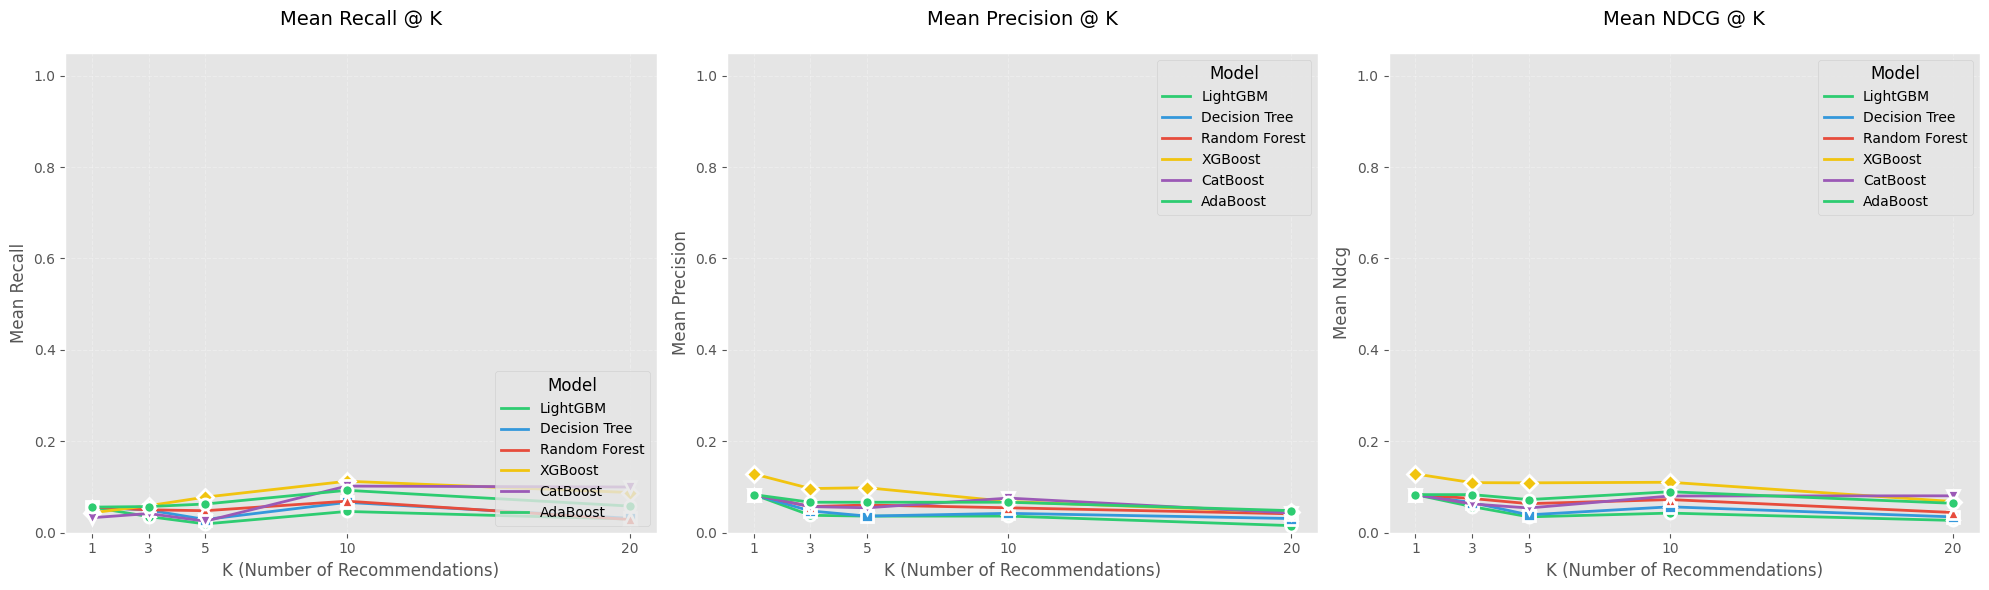

In [412]:
models_results = [results_lgb_full, results_dt, results_rf, results_xgb, results_cat, results_ada]
model_names = ['LightGBM', 'Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost', 'AdaBoost']

print_comparison_report(models_results, model_names)

metrics_fig = plot_metrics_comparison(
    models_results=models_results,
    model_names=model_names,
    k_values=[1, 3, 5, 10, 20]
)